In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

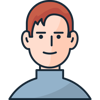

In [4]:
img = Image.open('../img/rotation_image.png')
img = img.resize((100, 100))
img

In [13]:
img_array = np.array(img)
h, w = img_array.shape[:2]

# convert to grayscale for simplicity
gray = np.mean(img_array, axis=2)

# center the data
mean = np.mean(gray, axis=0)
centered = gray - mean

# compute covariance matrix
cov_matrix = np.cov(centered.T)

# find eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(cov_matrix)

eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)

# sort eigenvalues in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# project data onto eigenvectors (PCA)
projection = centered @ eigvecs
projection

array([[ 7.17537899e+02,  4.82073005e+02,  3.53642505e+02, ...,
        -1.60141071e-11, -1.60141071e-11, -1.06377812e-11],
       [ 6.92497956e+02,  4.18180153e+02,  2.70840394e+02, ...,
         1.09652006e-11,  1.09652006e-11,  7.61606164e-12],
       [ 6.43433633e+02,  3.09682506e+02,  1.53357763e+02, ...,
         7.20909402e-12,  7.20909402e-12,  1.75763678e-12],
       ...,
       [-6.36367998e+02,  5.74990117e+02, -3.14380581e+02, ...,
        -3.62906162e-13, -3.62906162e-13,  1.37612716e-12],
       [-5.84544835e+01,  5.77579587e+02, -7.75229814e+00, ...,
        -4.86854508e-12, -4.86854508e-12,  1.79808823e-12],
       [ 7.70000134e+01,  5.80805381e+02,  6.77088300e+01, ...,
         4.85442735e-12,  4.85442735e-12, -3.11162329e-12]],
      shape=(100, 100))

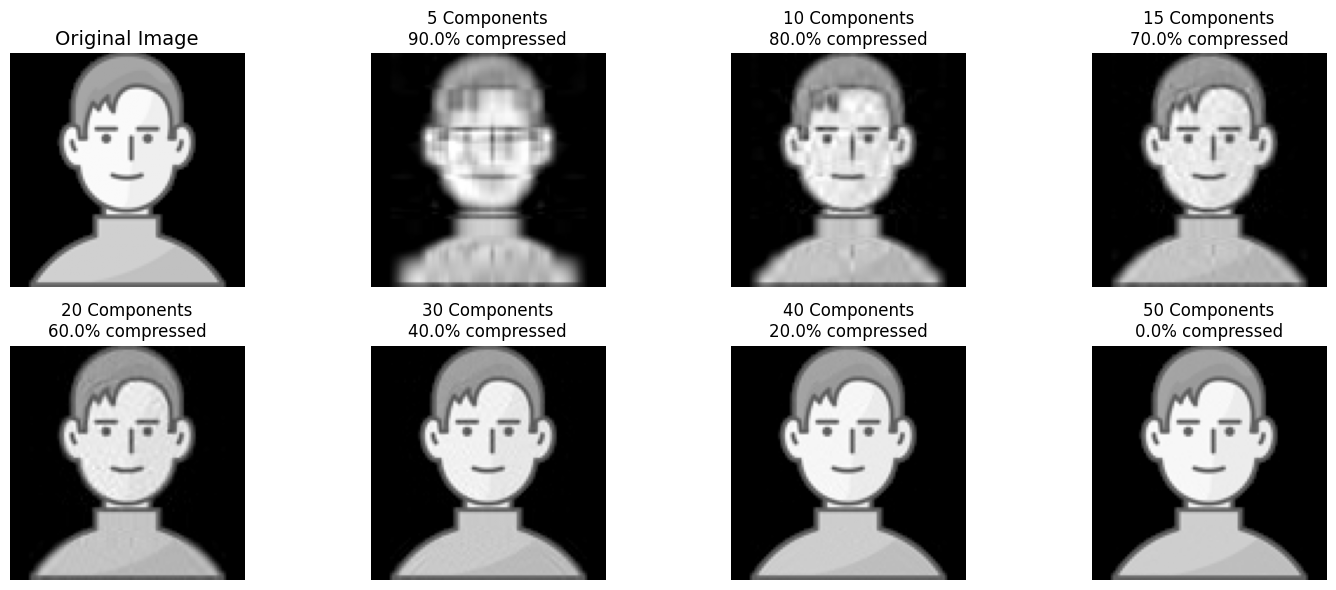

In [22]:
# reconstruct with different numbers of components
n_components = [5, 10, 15, 20, 30, 40, 50]

plt.figure(figsize=(15, 6))
plt.subplot(2, 4, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Image', fontsize=14)
plt.axis('off')

# Show compressed versions
for i, n in enumerate(n_components):
    # reconstruct using only top n components
    reconstructed = (projection[:, :n] @ eigvecs[:, :n].T) + mean
    reconstructed = np.clip(reconstructed, 0, 255)
    
    plt.subplot(2, 4, i + 2)
    plt.imshow(reconstructed, cmap='gray')
    
    # calculate compression ratio
    original_size = w * h
    compressed_size = w * n + n * h  # store components + eigenvectors
    ratio = (1 - compressed_size / original_size) * 100
    
    plt.title(f'{n} Components\n{ratio:.1f}% compressed', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.savefig('022_eigen_and_compression', dpi=70)